In [1]:
# load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency, pearsonr

In [2]:
# Load the children data
children_data = pd.read_csv('exp3_sum.csv')
children_data = children_data.iloc[:,:13]
# add subject info
sub_info =pd.read_excel('Subject_information.xlsx', sheet_name='Exp_03_Development_N=135', usecols='A:B')
# Merge the two DataFrames on 'sub' and 'Subject'
children_data = children_data.merge(sub_info, left_on='sub', right_on='Subject').drop(columns='Subject')
children_data['Gender'] = children_data['Gender'].map({0: 'F', 1: 'M'})
# Display the first few rows
print(children_data.head())

   sub  age    image_name  image_no  direction            RT  first_fix  \
0   10    1  ID_08_17.jpg         8         17  14819.960399          1   
1   10    1  ID_09_17.jpg         9         17  12752.770500          1   
2   10    1  ID_18_71.jpg        18         71  19361.045999          0   
3   10    1  ID_15_71.jpg        15         71   9105.401600          0   
4   10    1  ID_19_71.jpg        19         71  13223.301600          0   

   Time_face_h  Time_face_l  Time_eye_h  Time_eye_l  Time_nose_h  Time_nose_l  \
0     0.417582     0.582418    0.276060    0.177143     0.133722     0.302968   
1     0.583809     0.416191    0.190299    0.289879     0.183101     0.164906   
2     0.601186     0.373010    0.275233    0.205649     0.308947     0.068724   
3     0.332193     0.582041    0.122223    0.309215     0.155474     0.159224   
4     0.317133     0.603579    0.181160    0.432880     0.114336     0.108238   

  Gender  
0      F  
1      F  
2      F  
3      F  
4      

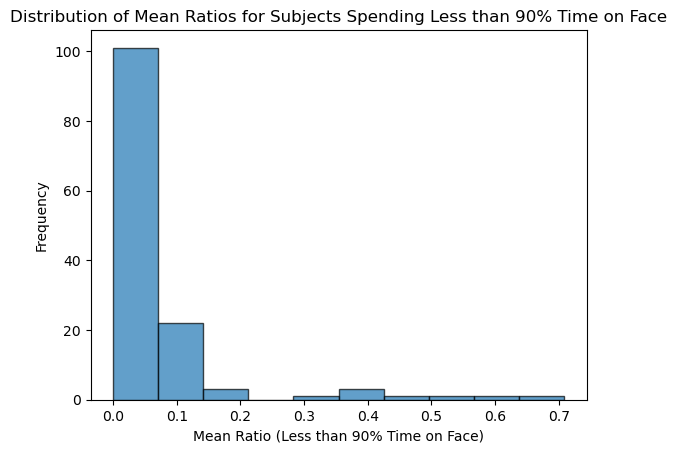

In [3]:
children_data['Time_face'] = children_data['Time_face_h'] + children_data['Time_face_l']
# Create a new column to check if time spent on face is less than 90%
children_data['Less_90_face'] = children_data['Time_face'] < 0.80
#data.to_csv('Children_all.csv')
# Group by 'sub' and compute the mean ratio for each subject
mean_ratio = children_data.groupby('sub')['Less_90_face'].mean()
# Plot a histogram to show the distribution of the mean ratios
plt.hist(mean_ratio, bins=10, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Mean Ratio (Less than 90% Time on Face)')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Ratios for Subjects Spending Less than 90% Time on Face')

# Display the plot
plt.show()


choice   proportion_left  proportion_right
sub age                                   
1   2           0.250000          0.750000
2   2           0.625000          0.375000
3   1           0.750000          0.250000
4   2           0.500000          0.500000
5   2           0.666667          0.333333
...                  ...               ...
164 3           0.416667          0.583333
165 3           0.291667          0.708333
166 4           0.125000          0.875000
167 3           0.333333          0.666667
168 4           0.708333          0.291667

[134 rows x 2 columns]


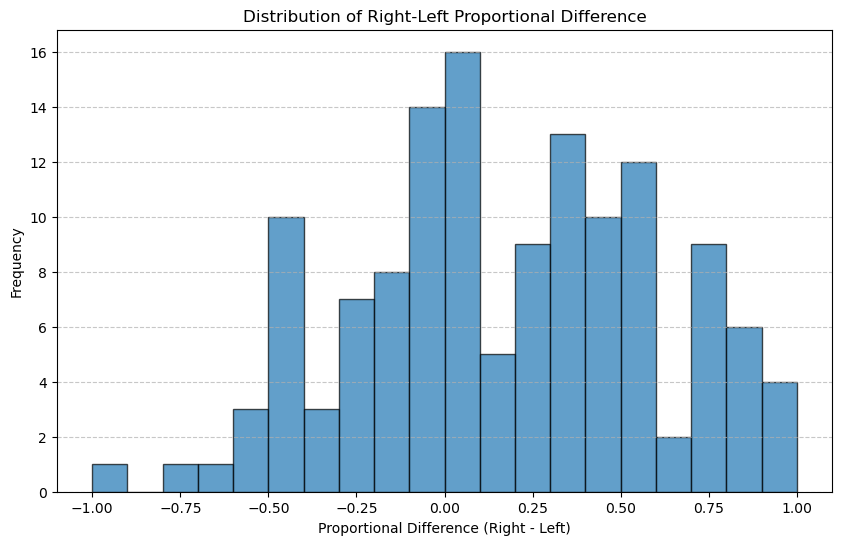

In [4]:
# Step 1: Determine left/right choice for each trial
def determine_choice(row):
    if row['direction'] == 17:  # Low face on the left
        return 'left' if row['Time_face_l'] > row['Time_face_h'] else 'right'
    elif row['direction'] == 71:  # Low face on the right
        return 'right' if row['Time_face_l'] > row['Time_face_h'] else 'left'
    else:
        return None  # Handle unexpected cases

data = children_data.copy()  # Create a copy to avoid the warning
data['choice'] = data.apply(determine_choice, axis=1)

# Step 2: Compute subject-level directional bias
subject_bias = data.groupby(['sub','age'])['choice'].value_counts(normalize=True).unstack(fill_value=0)

# Rename columns for clarity
subject_bias.rename(columns={'left': 'proportion_left', 'right': 'proportion_right'}, inplace=True)

# Display the results
print(subject_bias)

# Compute the difference (right - left) for each subject
subject_bias['difference_right_left'] = subject_bias['proportion_right'] - subject_bias['proportion_left']

# Plot the distribution of differences
plt.figure(figsize=(10, 6))
plt.hist(subject_bias['difference_right_left'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Right-Left Proportional Difference')
plt.xlabel('Proportional Difference (Right - Left)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [5]:
# Filter out subjects whose mean ratio is more than 30%
filtered_subjects = mean_ratio[mean_ratio <= 0.30].index

# Keep only the data for subjects whose mean ratio is 30% or less
filtered_data = data[data['sub'].isin(filtered_subjects)]

# Subjects that were removed (mean ratio > 30%)
removed_subjects = mean_ratio[mean_ratio > 0.30].index

# Filter the data to keep only the subjects whose mean ratio is <= 30%
filtered_data = data[data['sub'].isin(filtered_subjects)]

# Count the number of unique subjects in each age group
subjects_per_age_group = data.groupby('age')['sub'].nunique()
# Show the number of subjects in each age group after filtering
subjects_per_age_group_after = filtered_data.groupby('age')['sub'].nunique()

# Show the number of removed subjects
removed_subject_count = len(removed_subjects)

# Display the results
print("\nNumber of subjects before and after:", data['sub'].nunique(), filtered_data['sub'].nunique())
print("\nNumber of subjects removed:", removed_subject_count)
print("\nSubjects removed (IDs):", list(removed_subjects))
print("\nNumber of subjects in each age group before and after filtering:")
subjects_per_group_comparisions = pd.DataFrame({"Before":subjects_per_age_group, "After":subjects_per_age_group_after})
print(subjects_per_group_comparisions)



Number of subjects before and after: 134 126

Number of subjects removed: 8

Subjects removed (IDs): [3, 44, 47, 50, 68, 78, 85, 88]

Number of subjects in each age group before and after filtering:
     Before  After
age               
1        21     16
2        41     40
3        39     37
4        17     17
5        16     16


In [6]:
# Load the adult data
adult_data = pd.read_csv('exp1.csv')
adult_data = adult_data.iloc[:,:12]
# add subject info
adult_sub_info =pd.read_excel('Subject_information.xlsx', sheet_name='Exp_01_Adult_N=51', usecols='A:B')
# Merge the two DataFrames on 'sub' and 'Subject'
adult_data = adult_data.merge(adult_sub_info, left_on='sub', right_on='Num').drop(columns='Num')
adult_data['Gender'] = adult_data['Gender'].map({0: 'F', 1: 'M'})
adult_data.head()
# Display the first few rows
print(adult_data .head())

   sub    image_name  image_no  direction            RT  first_fix  \
0    1  ID_20_71.jpg        20         71  18317.208396          1   
1    1  ID_03_17.jpg         3         17  23077.325104          0   
2    1  ID_14_71.jpg        14         71  16837.440198          1   
3    1  ID_08_17.jpg         8         17  19203.782600          0   
4    1  ID_04_17.jpg         4         17  17329.192594          0   

   Time_face_h  Time_face_l  Time_eye_h  Time_eye_l  Time_nose_h  Time_nose_l  \
0     0.387130     0.579240    0.188181    0.234492     0.102641     0.249822   
1     0.365655     0.625370    0.116622    0.321494     0.207066     0.151542   
2     0.562259     0.418464    0.297035    0.294496     0.169145     0.122470   
3     0.462956     0.510148    0.214761    0.185755     0.165348     0.182395   
4     0.447251     0.537700    0.215168    0.160327     0.136390     0.227622   

  Gender  
0      F  
1      F  
2      F  
3      F  
4      F  


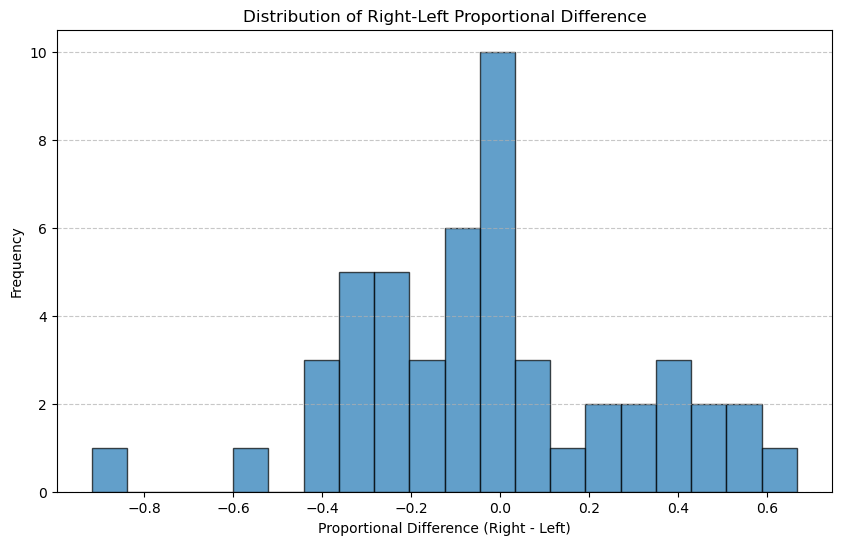

In [7]:
# analyze the directional bias of adults
adult_data = adult_data.copy()  # Create a copy to avoid the warning
adult_data['choice'] = adult_data.apply(determine_choice, axis=1)

# Compute subject-level directional bias
adult_subject_bias = adult_data.groupby('sub')['choice'].value_counts(normalize=True).unstack(fill_value=0)

# Rename columns for clarity
adult_subject_bias.rename(columns={'left': 'proportion_left', 'right': 'proportion_right'}, inplace=True)

# Display the results
# print(adult_subject_bias)

# Compute the difference (right - left) for each subject
adult_subject_bias['difference_right_left'] = adult_subject_bias['proportion_right'] - adult_subject_bias['proportion_left']

# Plot the distribution of differences
plt.figure(figsize=(10, 6))
plt.hist(adult_subject_bias['difference_right_left'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Right-Left Proportional Difference')
plt.xlabel('Proportional Difference (Right - Left)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


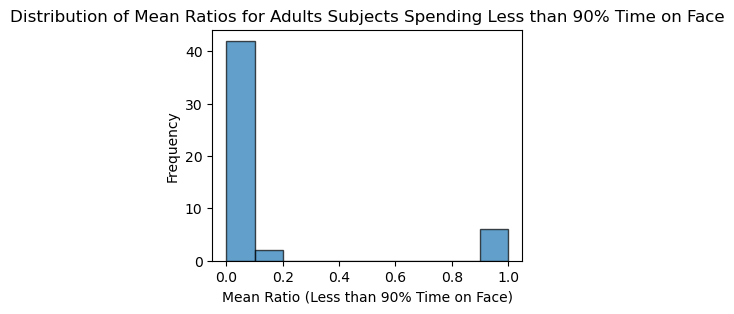

In [8]:
adult_data['Time_face'] = adult_data['Time_face_h'] + adult_data['Time_face_l']
# Create a new column to check if time spent on face is less than 90%
adult_data['Less_90_face'] = adult_data['Time_face'] < 0.80

# Group by 'sub' and compute the mean ratio for each subject
adult_mean_ratio = adult_data.groupby('sub')['Less_90_face'].mean()
# print(adult_mean_ratio)
# Plot a histogram to show the distribution of the mean ratios
plt.figure(figsize=(4,3))
plt.hist(adult_mean_ratio, bins=10, edgecolor='black', alpha=0.7)
# Add labels and title
plt.xlabel('Mean Ratio (Less than 90% Time on Face)')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Ratios for Adults Subjects Spending Less than 90% Time on Face')

# Display the plot
plt.show()

In [9]:
adult_data.head()

,sub,image_name,image_no,direction,RT,first_fix,Time_face_h,Time_face_l,Time_eye_h,Time_eye_l,Time_nose_h,Time_nose_l,Gender,choice,Time_face,Less_90_face
0,1,ID_20_71.jpg,20,71,18317.208396,1,0.387130,0.579240,0.188181,0.234492,0.102641,0.249822,F,right,0.966370,False
1,1,ID_03_17.jpg,3,17,23077.325104,0,0.365655,0.625370,0.116622,0.321494,0.207066,0.151542,F,left,0.991025,False
2,1,ID_14_71.jpg,14,71,16837.440198,1,0.562259,0.418464,0.297035,0.294496,0.169145,0.122470,F,left,0.980723,False
3,1,ID_08_17.jpg,8,17,19203.782600,0,0.462956,0.510148,0.214761,0.185755,0.165348,0.182395,F,left,0.973104,False
4,1,ID_04_17.jpg,4,17,17329.192594,0,0.447251,0.537700,0.215168,0.160327,0.136390,0.227622,F,left,0.984951,False


In [10]:
# import adult data, only the first touch
adult_fix = adult_data[['sub','first_fix','Gender']].copy()
adult_fix['age'] = 6
adult_fix['sub'] = adult_fix['sub'] + 200

# all data or filter data?
children_fix = children_data[['sub','age','first_fix','Gender']]
fix_data = pd.concat([adult_fix, children_fix], axis=0)
# Map 0 to 1 and 1 to 0
fix_data['first_fix'] = fix_data['first_fix'].map({0: 1, 1: 0})
# Convert columns to categorical
fix_data['age'] = fix_data['age'].astype('category')
fix_data.head()

,sub,first_fix,Gender,age
0,201,0,F,6
1,201,1,F,6
2,201,0,F,6
3,201,1,F,6
4,201,1,F,6


In [11]:
contingency_table = pd.crosstab(fix_data['age'], fix_data['first_fix'])

print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2}")
print(f"P-value: {p_value}")
print(f"Degrees of Freedom: {dof}")

Contingency Table:
first_fix    0    1
age                
1          117  387
2          245  739
3          316  620
4          171  237
5          162  222
6          503  697

Chi-Square Statistic: 118.21050176358887
P-value: 7.51091673208456e-24
Degrees of Freedom: 5


In [12]:
# use logstic regression
# Fit the logistic regression model
model = smf.logit("first_fix ~ age*Gender", data=fix_data).fit()

# Display the summary of the model
print(model.summary())

# Get predicted probabilities if needed
fix_data['predicted_prob'] = model.predict(fix_data)
print(np.exp(model.params))

Optimization terminated successfully.
         Current function value: 0.626602
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              first_fix   No. Observations:                 4416
Model:                          Logit   Df Residuals:                     4404
Method:                           MLE   Df Model:                           11
Date:                Thu, 16 Jan 2025   Pseudo R-squ.:                 0.02536
Time:                        15:36:08   Log-Likelihood:                -2767.1
converged:                       True   LL-Null:                       -2839.1
Covariance Type:            nonrobust   LLR p-value:                 2.519e-25
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.8650      0.149      5.805      0.000       0.573       1.157

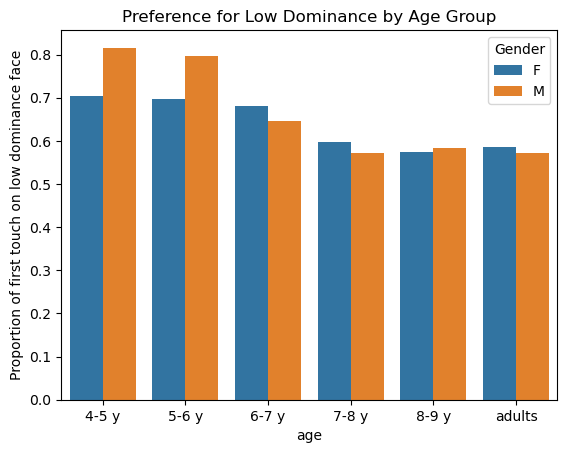

In [13]:
# Calculate the proportion of high dominance choices in each age group
proportions = fix_data.groupby(['age','Gender'])['first_fix'].mean().reset_index()

# Bar plot of proportions
ax = sns.barplot(x='age', y='first_fix', hue='Gender',data=proportions)
ax.set_xticklabels(['4-5 y', '5-6 y', '6-7 y', '7-8 y', '8-9 y', 'adults'])
plt.ylabel('Proportion of first touch on low dominance face')
plt.title('Preference for Low Dominance by Age Group')
plt.show()

In [14]:
# Reshape the data for Face, Eye, and Nose time in high and low dominance
melted_data_regions = pd.melt(filtered_data, id_vars=['age', 'sub','Gender'], 
                              value_vars=['Time_face_h', 'Time_face_l', 'Time_eye_h', 'Time_eye_l', 'Time_nose_h', 'Time_nose_l'], 
                              var_name='Region_Dominance', value_name='Time')

melted_data_regions['Region'] = melted_data_regions['Region_Dominance'].str.split('_').str[1].str.capitalize()
melted_data_regions['Dominance'] = melted_data_regions['Region_Dominance'].str.split('_').str[2].str.capitalize()
melted_data_regions['Region'] = melted_data_regions['Region'].astype(pd.CategoricalDtype(categories=['Face','Eye','Nose'], ordered=True))
melted_data_regions['Dominance']  = melted_data_regions['Dominance'] .astype(pd.CategoricalDtype(categories=['H','L'], ordered=True))

/home/common/softs/anaconda/anaconda3/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/common/softs/anaconda/anaconda3/lib/python3.8/site-packages/seaborn/axisgrid.py:181: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  figlegend = self._figure.legend(handles, labels, **kwargs)


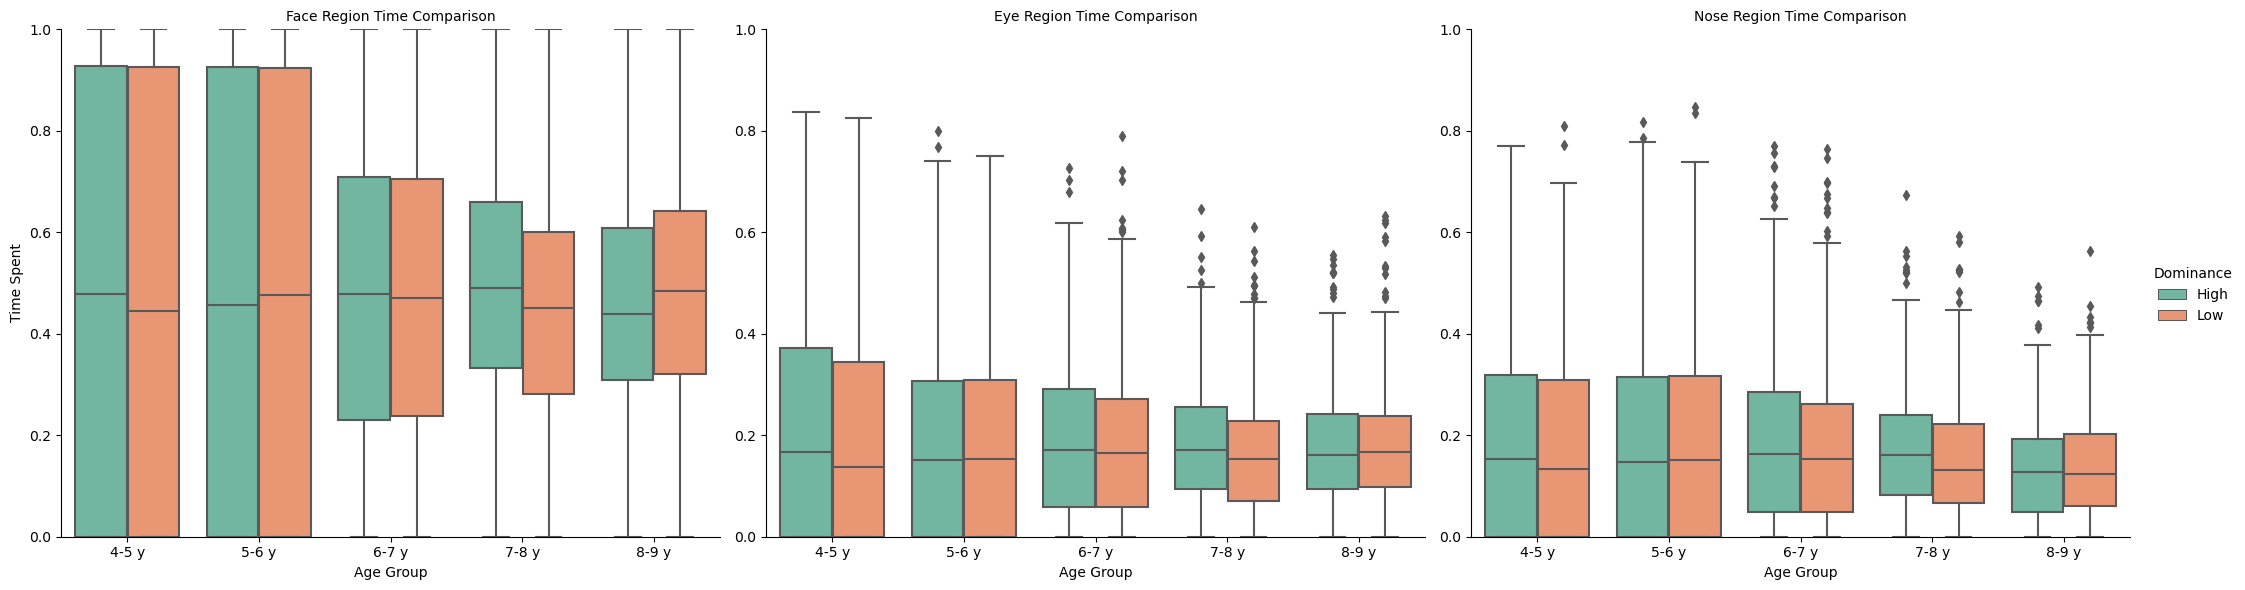

In [15]:
# Create a FacetGrid to plot boxplots for Face, Eye, and Nose with dominance as color
g = sns.FacetGrid(melted_data_regions, col="Region", col_order=["Face", "Eye", "Nose"], height=6, aspect=1.2, sharey=False)
g.map_dataframe(sns.boxplot, x="age", y="Time", hue="Dominance", palette="Set2")

g.set(ylim=(0, 1))

# Set labels and titles
g.set_axis_labels("Age Group", "Time Spent")
g.set_titles("{col_name} Region Time Comparison")

# Add a legend for dominance
handles, labels = g.axes[0, 0].get_legend_handles_labels()
g.add_legend(title="Dominance", handles=handles, labels=['High', 'Low'])
g.set_xticklabels(['4-5 y', '5-6 y', '6-7 y', '7-8 y', '8-9 y'])
# Show the plot
plt.show()

In [16]:
# combine the 4th and 5th group data and do ANOVA
old_children_data = melted_data_regions[melted_data_regions['age'].isin([4, 5])]

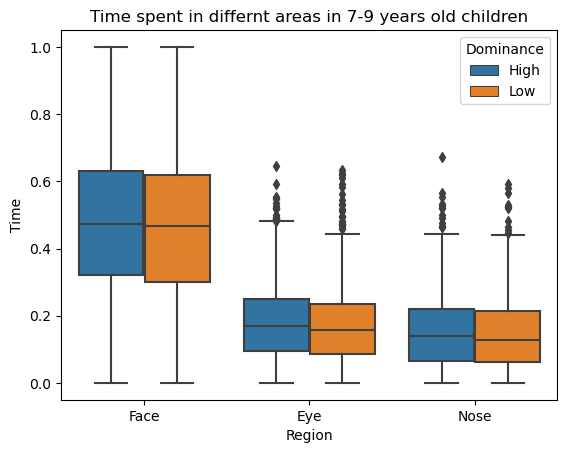

In [17]:
ax = sns.boxplot(x='Region', y='Time', hue='Dominance', data=old_children_data)
new_labels = ['High','Low'] # Replace with your desired labels
handles, _ = ax.get_legend_handles_labels()  # Get existing legend handles
ax.legend(handles, new_labels, title="Dominance")
plt.title('Time spent in differnt areas in 7-9 years old children')
plt.show()

In [18]:
# test if the dominance preference is correlated with the FWHR
adult_data['dom_diff'] = adult_data['Time_face_l'] - adult_data['Time_face_h']
adult_diff = adult_data[['image_no','dom_diff']].groupby('image_no').mean('dom_diff')

filtered_data.loc[:, 'dom_diff'] = filtered_data['Time_face_l'] - filtered_data['Time_face_h']
old_children_filtered = filtered_data[filtered_data['age'].isin([4, 5])]
children_diff = old_children_filtered[['image_no','dom_diff']].groupby('image_no').mean('dom_diff')

fwhr = pd.read_excel('FWHR.xlsx',header=1)
fwhr['dominance'] = np.where(
    # Condition for "low"
    ((fwhr['figure'].str.endswith('17') & (fwhr['location'] == 'left')) |
     (fwhr['figure'].str.endswith('71') & (fwhr['location'] == 'right'))),
    "low",
    "high"
)
fwhr['ratio'] = fwhr['width']/fwhr['height']
pivot_fwhr= fwhr.pivot(index='figure', columns='dominance', values='ratio')
pivot_fwhr = pivot_fwhr.reset_index()
pivot_fwhr.loc[:,'diff'] = pivot_fwhr['low'] - pivot_fwhr['high']
# Pearson correlation
adult_corr, adult_p = pearsonr(adult_diff['dom_diff'], pivot_fwhr['diff'])
print(f"Pearson's r for adults = {adult_corr}, p-value = {adult_p}")

# Pearson correlation
children_corr, children_p = pearsonr(children_diff['dom_diff'], pivot_fwhr['diff'])
print(f"Pearson's r for children = {children_corr}, p-value = {children_p}")

Pearson's r for adults = 0.5289300460347416, p-value = 0.007872454085134492
Pearson's r for children = -0.37933685866217937, p-value = 0.06752299168317796


/tmp/ipykernel_40307/2558028057.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.loc[:, 'dom_diff'] = filtered_data['Time_face_l'] - filtered_data['Time_face_h']
